In [2]:
!pip install faiss-cpu

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 16.1 MB/s eta 0:00:0000:0100:01


In [1]:
import random
import time
from pyflim import flim, arch, data, metrics, util
import numpy as np
from torch.utils.data import DataLoader
import torch

## Create Dataset

In [ ]:
orig_folder = "data/orig/"
marker_folder = "data/markers_gt/"
label_folder = "data/label/"
activations_folder="activations/"
orig_ext = ".png"
label_ext = ".png"
marker_ext = ".png" #"-seeds.txt"
file_list = "./train.txt"

train_by_batch=True
if(not train_by_batch):
    dataset = data.FLIMData(orig_folder, images_list=file_list, marker_folder=marker_folder, orig_ext=orig_ext, marker_ext=marker_ext,
                                                 transform=data.transforms.Compose([data.ToTensor()]))
else:
    dataset_ = data.FLIMData(orig_folder, images_list=file_list, label_folder=label_folder, label_ext=label_ext, marker_folder=marker_folder, orig_ext=orig_ext, marker_ext=marker_ext,
                                                 transform=data.transforms.Compose([
                                                     data.Rescale(256),
                                                     data.ToTensor()]))
    sampler = torch.utils.data.sampler.BatchSampler(torch.utils.data.sampler.RandomSampler(dataset_),
                                                    batch_size=5,drop_last=False)

    dataset = DataLoader(dataset_, batch_sampler=sampler)

## Train model

In [3]:
architecture = arch.FLIMArchitecture("arch.json")
model = flim.FLIMModel(architecture, adaptation_function="robust_weights", device="cpu", filter_by_size=False, track_gpu_stats=True)
start = time.time()
model.fit(dataset)
stop = time.time()
print('Network trained in:', stop - start, 'seconds')

Network trained in: 26.669338703155518 seconds


In [4]:
start = time.time()
model.run(dataset, output_folder="out_gt_markers_train/", activations_folder="activations/")
stop = time.time()
print('Forward pass in:', stop - start, 'seconds')

Forward pass in: 3.4087438583374023 seconds


In [5]:
print("Model parameters: ", util.get_model_n_params(model), "(M)")

Model parameters:  2.738 (M)


### Run on validation

In [6]:
file_list = "./val.txt"

train_by_batch=False
if(not train_by_batch):
    dataset = data.FLIMData(orig_folder, images_list=file_list, orig_ext=orig_ext,
                                                 transform=data.transforms.Compose([data.ToTensor()]))
else:
    dataset_ = data.FLIMData(orig_folder, images_list=file_list, orig_ext=orig_ext,
                                                 transform=data.transforms.Compose([
                                                     data.Rescale(256),
                                                     data.ToTensor()]))
    sampler = torch.utils.data.sampler.BatchSampler(torch.utils.data.SequentialSampler(dataset_),
                                                    batch_size=5,drop_last=False)

    dataset = DataLoader(dataset_, batch_sampler=sampler)

start = time.time()
model.run(dataset, output_folder="out_gt_markers_val/", activations_folder="activations/")
stop = time.time()
print('Forward pass in:', stop - start, 'seconds')

Forward pass in: 0.8828897476196289 seconds


### Compute Metrics

In [7]:
from pyflim import flim, arch, data, metrics, util
file_list = "./val.txt"
label_folder = "data/label/"
results_folder = "out/"

metricas = metrics.FLIMMetrics()
metricas.evaluate_saliency_results(results_folder, label_folder, file_list=util.readFileList(file_list))

In [8]:
metricas.print_results()

Method       | uWF-M |   MAE |  E-M  | DICE 
Flim         | 0.643 | 0.005 | 0.605 | 0.907


OBSERVACOES

No arquivo markers/**.txt as clases 0 sao marcadores do fundo, enquanto as classes 1 sao marcadores de objeto

Using default paths. To specify paths, run as: python marker_comparisson.py <txt_file> <png_file>
TXT: data/markers/000137-seeds.txt
PNG: data/label/000137.png

Error loading TXT image data/markers/000137-seeds.txt: [Errno 2] No such file or directory: 'data/markers/000137-seeds.txt'


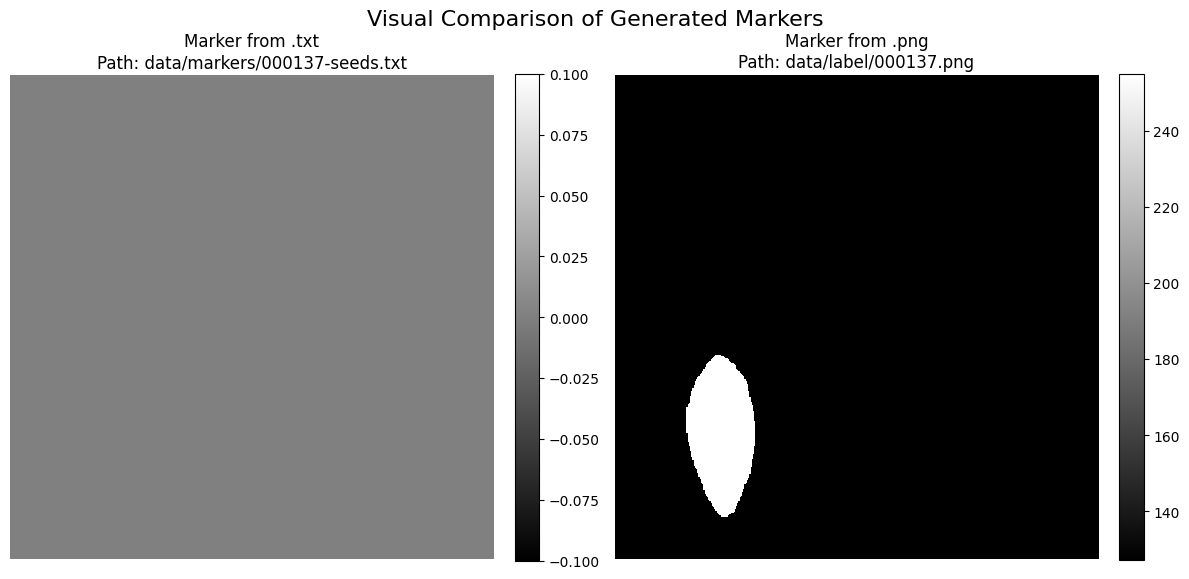

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import sys
from pyflim.data import FLIMData

txt_marker_path = "data/markers/000137-seeds.txt"
png_marker_path = "data/label/000137.png" 

if len(sys.argv) == 3:
    txt_marker_path = sys.argv[1]
    png_marker_path = sys.argv[2]
    print(f"Comparing user-provided files:\nTXT: {txt_marker_path}\nPNG: {png_marker_path}")
else:
    print("Using default paths. To specify paths, run as: python marker_comparisson.py <txt_file> <png_file>")
    print(f"TXT: {txt_marker_path}\nPNG: {png_marker_path}\n")
# Generate marker images using the newly modified get_marker_image function
try:
    txt_image = FLIMData.get_marker_image(txt_marker_path)
except Exception as e:
    print(f"Error loading TXT image {txt_marker_path}: {e}")
    txt_image = None
    
try:
    png_image = FLIMData.get_marker_image(png_marker_path)
except Exception as e:
    print(f"Error loading PNG image {png_marker_path}: {e}")
    png_image = None
if txt_image is None and png_image is None:
    print("Failed to load both images. Exiting.")

# Increase the markers value so it can be visualized clearly
# By normalizing by the maximum value and multiplying by 255, 
# the classes become highly visible white/gray pixels against the black background.

if txt_image is not None:
    txt_max = txt_image.max() if txt_image.max() > 0 else 1
    txt_vis = (txt_image / txt_max * 255).astype(np.uint8)
else:
    txt_vis = np.zeros((100, 100)) # Placeholder if failed
if png_image is not None:
    png_max = png_image.max() if png_image.max() > 0 else 1
    png_vis = (png_image / png_max * 255).astype(np.uint8)
else:
    png_vis = np.zeros((100, 100)) # Placeholder if failed

# Create a visual comparison using matplotlib
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
im1 = axes[0].imshow(txt_vis, cmap='gray', interpolation='nearest')
axes[0].set_title(f"Marker from .txt\nPath: {txt_marker_path}")
axes[0].axis('off')
im2 = axes[1].imshow(png_vis, cmap='gray', interpolation='nearest')
axes[1].set_title(f"Marker from .png\nPath: {png_marker_path}")
axes[1].axis('off')
# Add colorbars to indicate the intensity values
fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)
fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)
plt.suptitle("Visual Comparison of Generated Markers", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
import os
import ipywidgets as widgets
from IPython.display import display, Image

def create_visualizer():
    if not os.path.exists(activations_folder):
        print(f"Directory '{activations_folder}' not found.")
        return

    # Get all image files in the activations folder
    files = [f for f in os.listdir(activations_folder) if f.endswith('.png') or f.endswith('.jpg')]
    
    if not files:
        print(f"No image files found in '{activations_folder}'.")
        return

    # The layer is represented by the first character, the rest by the remaining string
    layers = sorted(list(set(f[0] for f in files)))
    rest_of_names = sorted(list(set(f[1:] for f in files)))

    layer_slider = widgets.SelectionSlider(
        options=layers,
        description='Layer:',
        disabled=False,
        style={'description_width': 'initial'},
        layout={'width': '400px'}
    )

    rest_slider = widgets.SelectionSlider(
        options=rest_of_names,
        description='Rest of Name:',
        disabled=False,
        style={'description_width': 'initial'},
        layout={'width': '400px'}
    )

    out = widgets.Output()

    def update_image(layer, rest):
        with out:
            out.clear_output(wait=True)
            filename = layer + rest
            filepath = os.path.join(activations_folder, filename)
            if os.path.exists(filepath):
                display(Image(filename=filepath))
            else:
                print(f"File not found: {filename}")

    def on_slider_change(change):
        if change['type'] == 'change' and change['name'] == 'value':
            update_image(layer_slider.value, rest_slider.value)

    layer_slider.observe(on_slider_change, names='value')
    rest_slider.observe(on_slider_change, names='value')

    # Display the UI components
    display(widgets.VBox([layer_slider, rest_slider, out]))

    # Render the initial image
    if layers and rest_of_names:
        update_image(layer_slider.value, rest_slider.value)

create_visualizer()